# TP1 (a completer) : K-means + ACP — *Iris*

Remplacez chaque `...` et chaque `# TODO`. Le corrige (`../notebooks/TP1_kmeans_acp.ipynb`)
applique la **meme demarche sur un AUTRE dataset (Wine)** : la structure est
identique, seules les donnees et les colonnes changent : a vous d'adapter.

**Objectif.** Retrouver, par clustering, les **3 especes** de 150 fleurs d'iris
decrites par **4 mesures** (longueur/largeur des petales et des sepales), sans
utiliser l'etiquette ; puis valider et qualifier.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import load_iris
ds = load_iris(as_frame=True)
X = ds.data
espece = ds.target     # 0,1,2 : garde de cote pour la validation
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [7]:
# TODO : statistiques descriptives (indice : .describe())
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [39]:
from sklearn.preprocessing import StandardScaler

# TODO : creer X_std en standardisant X
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pd.DataFrame(X_std, columns=X.columns).describe().round(2).loc[['mean', 'std']].T.head()


,mean,std
sepal length (cm),-0.0,1.0
sepal width (cm),-0.0,1.0
petal length (cm),-0.0,1.0
petal width (cm),-0.0,1.0


## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
lisez le `k_best` qui maximise la silhouette. **Attention** : ce `k_best` ne
coincide pas toujours avec le vrai nombre de groupes.

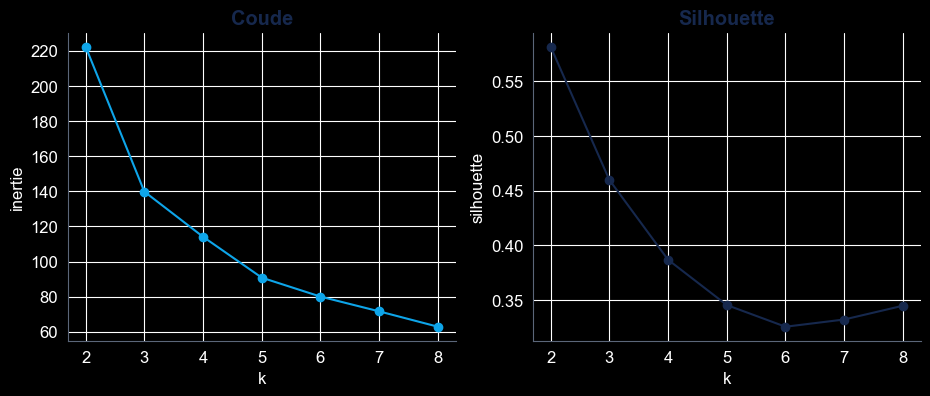

k retenu : 2


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)        # TODO : inertie
    silhouettes.append(silhouette_score(X_std, km.labels_))     # TODO : silhouette

k_best = list(ks)[int(np.argmax(silhouettes))]    # TODO : k de meilleure silhouette

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

> **A observer.** Sur Iris, la silhouette est maximale a **k = 2**, pas 3 : une
> espece (*setosa*) se detache tres nettement, alors que les deux autres se
> **chevauchent**. Comme on **sait** qu'il y a **3 especes**, on poursuit avec
> `k = 3` pour comparer le clustering a la realite (lecon : la silhouette ne donne
> pas toujours le vrai nombre de classes).

on prend k = 3 car visuellement c'est la valeur qui semble le plus pertinant

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec **`k = 3`**. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `espece` et
les clusters, et affichez le `pd.crosstab`.

In [21]:
from sklearn.metrics import adjusted_rand_score

k = 3                  # on connait 3 especes (cf. note ci-dessus)
km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
labels = km.labels_
# TODO : afficher silhouette et adjusted_rand_score(espece, labels)
print(f"silhouette : {silhouette_score(X_std, labels):.2f}")
print(f"Adjusted Rand Index (clusters vs espece) : {adjusted_rand_score(espece, labels):.2f}")
# TODO : tableau croise clusters x espece
pd.crosstab(labels, espece, rownames=['cluster'], colnames=['espece'])

silhouette : 0.46
Adjusted Rand Index (clusters vs espece) : 0.62


espece,0,1,2
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

/var/folders/wl/zwhjd2sn3j37mnpq923s2yvw0000gn/T/ipykernel_16328/774719920.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


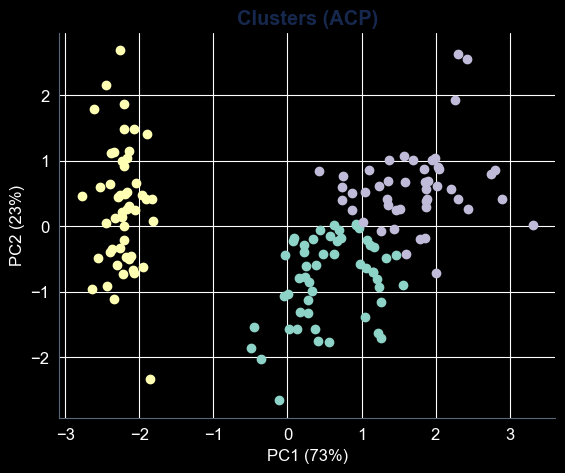

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)                 # TODO : fit_transform(X_std)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    # TODO : scatter des points du cluster c (coords[m, 0], coords[m, 1])
    ax.scatter(coords[m, 0], coords[m, 1])
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables cles par cluster. Ajoutez aussi l'effectif
de chaque cluster.

In [35]:
fleurs = X.copy()
fleurs["cluster"] = labels
cles = list(X.columns)   # les 4 mesures d'iris
# TODO : profil moyen par cluster (groupby + mean)
profil = fleurs.groupby('cluster').mean()
# TODO : ajouter une colonne "effectif" (nombre de fleurs par cluster)
profil["effectif"] = fleurs.groupby('cluster').size()
profil

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),effectif
cluster,,,,,
0,5.801887,2.673585,4.369811,1.413208,53
1,5.006000,3.428000,1.462000,0.246000,50
2,6.780851,3.095745,5.510638,1.972340,47


### 6.a Distribution par cluster : boxplots
**Consigne.** La moyenne **cache la dispersion**. Tracez un boxplot par cluster
pour les 4 mesures d'iris. Pour chaque sous-graphe, `paquets` doit etre la **liste
des valeurs de la variable, un element par cluster**. Reperez ensuite les variables
les plus **discriminantes** (boites bien separees).

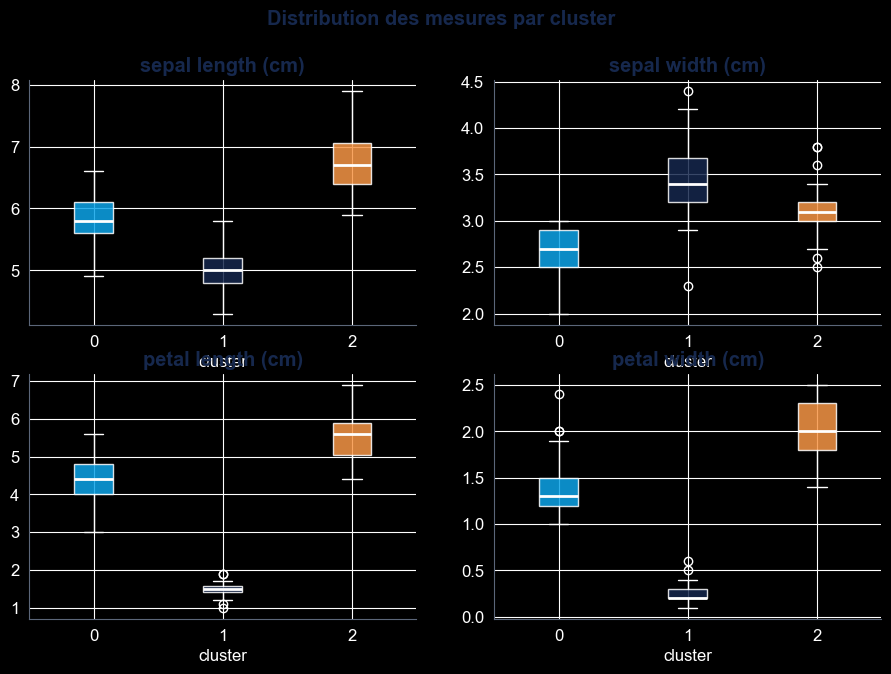

In [36]:
groupes = sorted(fleurs["cluster"].unique())
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), X.columns):
    # TODO : pour chaque cluster c de groupes, les valeurs fleurs[col] du cluster
    paquets = [fleurs.loc[fleurs["cluster"] == c, col] for c in groupes]
    bp = ax.boxplot(paquets, patch_artist=True, medianprops=dict(color="white", lw=2))
    for patch, c in zip(bp["boxes"], groupes):
        patch.set(facecolor=PALETTE[c], alpha=0.85)
    ax.set_title(col); ax.set_xlabel("cluster")
    ax.set_xticks(range(1, len(groupes) + 1)); ax.set_xticklabels(groupes)
fig.suptitle("Distribution des mesures par cluster", color=NAVY, fontweight="bold")
plt.show()

`petal lenght` et `petal width` separent les clusters

### 6.b Signature complete : heatmap des moyennes standardisees
**Consigne.** Pour comparer les 4 variables d'un coup, calculez la **moyenne
standardisee** de chaque variable par cluster (sur `X_std`) et affichez-la en
heatmap. Rouge = au-dessus de la moyenne generale, bleu = en dessous. Donnez
ensuite un **nom** (un profil) a chaque cluster.

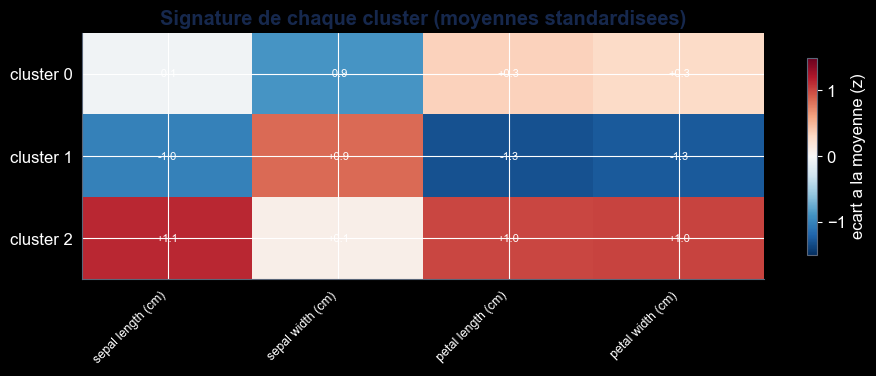

In [38]:
profil_z = pd.DataFrame(X_std, columns=X.columns)
profil_z["cluster"] = labels
# TODO : moyenne par cluster (groupby sur profil_z)
moyennes_z = profil_z.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(moyennes_z, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(X.columns)))
ax.set_xticklabels(X.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(moyennes_z)))
ax.set_yticklabels([f"cluster {c}" for c in moyennes_z.index])
for i in range(moyennes_z.shape[0]):
    for j in range(moyennes_z.shape[1]):
        ax.text(j, i, f"{moyennes_z.iloc[i, j]:+.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="ecart a la moyenne (z)")
ax.set_title("Signature de chaque cluster (moyennes standardisees)")
plt.show()

**Voici les clusters :**
> - un cluster **avec des groses pétales et sépal sepal/petal lenght** (sepal/petal lenght et width
>   eleves) : des grosses fleurs ;
> - un cluster **avec un sepal lenght, petal lenght et petal width plus faible que la moyenne**, mais avec des fortes sepal width : des fleurs larges mais petites par rapport aux autres
> - un cluster avec un sepal moins larges que les autres avec les autres valeurs dans la moyenne des données

## 7. Aller plus loin : le clustering hierarchique (CAH)

K-means n'est pas la seule methode de clustering. La **Classification Ascendante
Hierarchique (CAH)** procede autrement :

1. au depart, **chaque fleur est seule** dans son cluster ;
2. a chaque etape, on **fusionne les deux clusters les plus proches** ;
3. on continue jusqu'a n'avoir **qu'un seul cluster**.

L'historique des fusions se lit sur un **dendrogramme** : on le "coupe" a la
hauteur voulue pour obtenir k clusters. Avantage : pas besoin de fixer k a
l'avance, et la structure est visible.

**Consigne.** Tracez le dendrogramme (methode de Ward sur `X_std`), puis
recuperez 3 clusters avec `AgglomerativeClustering` et comparez-les aux clusters
K-means et aux vraies especes (ARI).

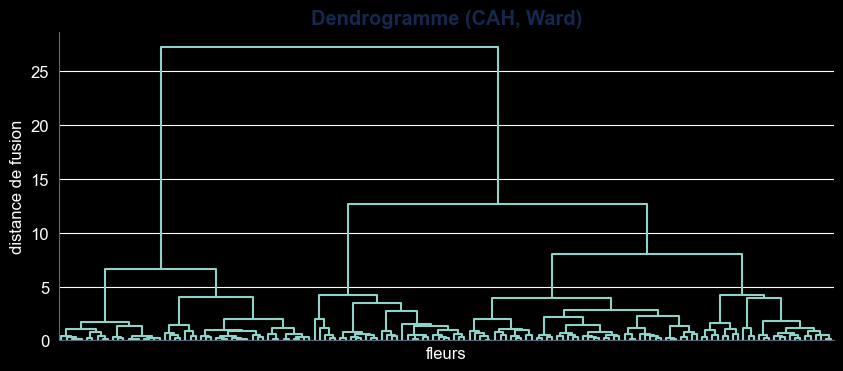

In [40]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Matrice de liaison (linkage) par la methode de Ward sur les donnees standardisees
Z = linkage(X_std, method="ward")                       # TODO : linkage(X_std, method="ward")

# 2. Dendrogramme
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=0, ax=ax)
ax.set(title="Dendrogramme (CAH, Ward)", xlabel="fleurs", ylabel="distance de fusion")
plt.show()

In [42]:
from sklearn.cluster import AgglomerativeClustering

# 3. Couper l'arbre pour obtenir 3 clusters
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_cah = cah.fit_predict(X_std)              # TODO : cah.fit_predict(X_std)

# 4. Comparer : CAH vs K-means, et CAH vs vraies especes (adjusted_rand_score)
# TODO : afficher les deux ARI
print(f"ARI CAH vs K-means : {adjusted_rand_score(labels, labels_cah):.3f}")
print(f"ARI CAH vs cepages : {adjusted_rand_score(espece, labels_cah):.3f}")
pd.crosstab(labels_cah, espece, rownames=["CAH"], colnames=["espece reelle"])

ARI CAH vs K-means : 0.626
ARI CAH vs cepages : 0.615


espece reelle,0,1,2
CAH,,,
0,0,23,48
1,49,0,0
2,1,27,2


## A rendre
- Ce que dit la silhouette sur le nombre de groupes, et pourquoi on retient `k = 3`.
- L'ARI obtenu et votre interpretation du tableau croise (quelle espece est la
  mieux retrouvee ? lesquelles se confondent ?).
- D'apres les **boxplots**, les 2 variables les plus discriminantes.
- Une phrase de qualification par cluster, appuyee sur la **heatmap** (signature).
- La comparaison **K-means vs CAH** (ARI) et ce que montre le dendrogramme.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?